Firstly, import everything necessary

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.io.fits as apfits
import astropy.table as aptable
import healpy as hp
import treecorr as tc
import iminuit as imin

In [48]:
catalogue_file_path = "/opt/shared-data/DESY3_LSSBAO_CATALOG.fits"

# Open the file
with apfits.open(catalogue_file_path) as data_fits:
    # create a table called `data_table` holding the data in the first extension
    data_table = aptable.Table(data_fits[1].data)

# create a variable holding the FITS file path
footprint_file_path = "/opt/shared-data/des_footprint.fits"

# open the footprint FITS file
with apfits.open(footprint_file_path) as des_footprint_fits:
    # create a table called `des_footprint_data` holding the data in the first extension
    des_footprint_data = aptable.Table(des_footprint_fits[1].data)

survey_num_per_pixel = int(  # convert to integer
    # use ceil to round up to next whole number
    np.ceil(len(data_table) / len(des_footprint_data))
)  # N galaxies / N pixels

synth_num_per_pixel = 2 * survey_num_per_pixel
print("Generate", synth_num_per_pixel, "fake galaxies per pixel.")

pixelsize = hp.nside2resol(4096, arcmin=True) / 60  # degrees

random_offsets = np.random.uniform(
    low=-pixelsize / 2,
    high=pixelsize / 2,
    size=(synth_num_per_pixel, 2, len(des_footprint_data))
).astype(np.float16)

pixel_coords = np.array(  # convert to a numpy array
    hp.pix2ang(  # calculate the coordinates for a set of pixels
        nside=4096,  # The nside value used to generate the footprint map
        ipix=des_footprint_data[
            "HPIX_4096"
        ],  # The pixel indices we need coordinates for
        nest=True,  # Specify that the NEST schema was used to generate the map
        lonlat=True,  # Specify that coordinates in degrees are required.
    ), dtype=np.float16
)

random_coords = pixel_coords + random_offsets
del pixel_coords, random_offsets

reshaped_random_coords = random_coords.swapaxes(0, 1).reshape(2, -1)
del random_coords

random_redshifts = np.random.uniform(
    low=0.6, high=1.1, size=reshaped_random_coords.shape[1]
    ).astype(np.float16)

random_table = aptable.Table(
    np.vstack([reshaped_random_coords, random_redshifts]).T, names=["RA", "DEC", "Z"]
)

random_selection = (random_table["DEC"] < -40) & (random_table["DEC"] > -45)

bin_edges = np.linspace(0.6, 1.1, 5)
z_min_vals, z_max_vals, z_mean_vals, results_omega, results_var, results_theta = [], [], [], [], [], []

Generate 2 fake galaxies per pixel.


We will use 4 slices, equidistant through the range $0.6 < z < 1.1$, where the interval is $0.125$ per slice. The first slice is therefore $z_{min}=0.6$ and $z_{max}=0.725$.

In [49]:
# Correlation Parameters, we will use **params instead of stating the parameters each time, bin_slop has been changed to 0.1 for optimisation.
params = dict(
    min_sep=0.5, 
    max_sep=5.0, 
    nbins=15, 
    sep_units="degrees", 
    bin_slop=0.1  
)

# Iterate through all slices
for i in range(4):
    z_min, z_max = bin_edges[i], bin_edges[i+1]
    print(f"Starting Bin {i+1}...")

    # Selection
    d_sel = select_z_bin(data_table, z_min, z_max, "DNF_ZMEAN_SOF")
    r_sel = select_z_bin(random_table, z_min, z_max, "Z")

    # Catalogs (No patches = much less RAM used)
    cat_d = tc.Catalog(ra=d_sel["RA"], dec=d_sel["DEC"], ra_units="deg", dec_units="deg")
    cat_r = tc.Catalog(ra=r_sel["RA"], dec=r_sel["DEC"], ra_units="deg", dec_units="deg")

    # Correlations
    dd = tc.NNCorrelation(**params)
    rr = tc.NNCorrelation(**params)
    dr = tc.NNCorrelation(**params)
    print("Correlation found...")
    
    dd.process(cat_d)
    rr.process(cat_r)
    dr.process(cat_d, cat_r)
    print("Processes complete...")

    # Calculate w(theta)
    omega, omega_variance = dd.calculateXi(rr=rr, dr=dr)
    results_theta.append(dd.meanr)
    print("w(theta calculated...)")
        
    # Store results
    z_min_vals.append(z_min)
    z_max_vals.append(z_max)
    z_mean_vals.append(np.mean(d_sel["DNF_ZMEAN_SOF"]))
    results_omega.append(omega)
    results_var.append(omega_variance)

    print(f"Bin {i+1} Complete: {len(d_sel)} galaxies.")

Starting Bin 1...
Correlation found...
Processes complete...
w(theta calculated...)
Bin 1 Complete: 1874991 galaxies.
Starting Bin 2...
Correlation found...
Processes complete...
w(theta calculated...)
Bin 2 Complete: 2158024 galaxies.
Starting Bin 3...
Correlation found...
Processes complete...
w(theta calculated...)
Bin 3 Complete: 1842931 galaxies.
Starting Bin 4...
Correlation found...
Processes complete...
w(theta calculated...)
Bin 4 Complete: 1156035 galaxies.


c)

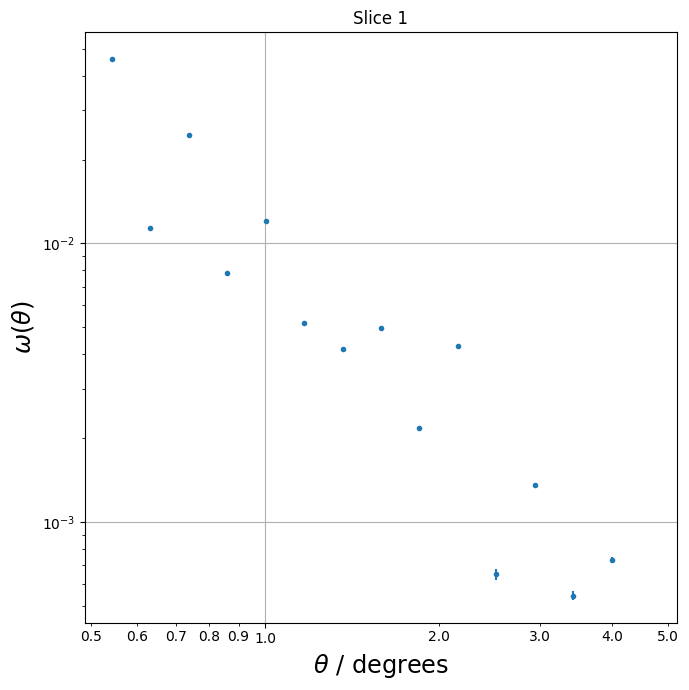

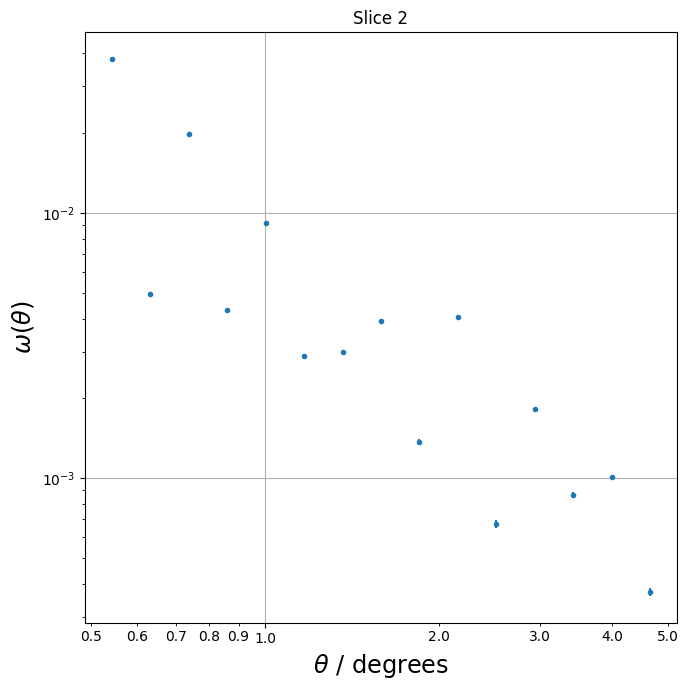

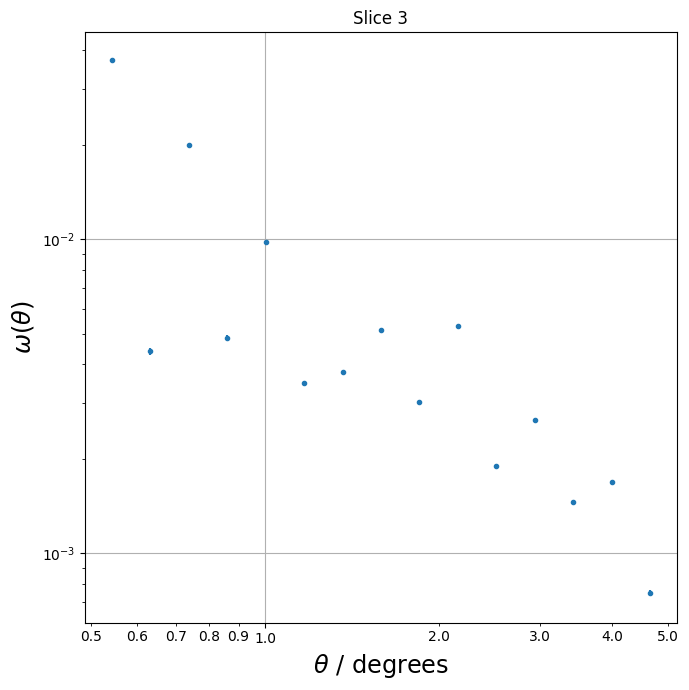

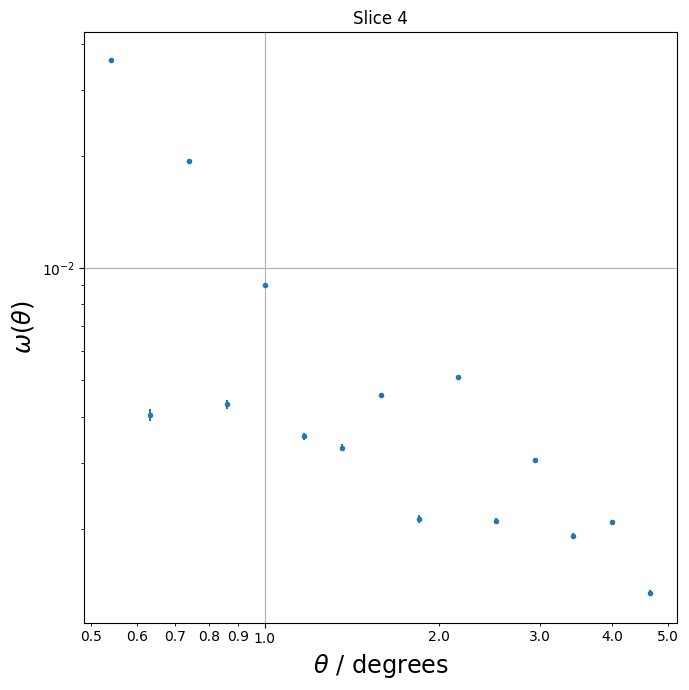

In [50]:
from matplotlib import ticker

for i in range(4):
    theta = dd.meanr
    omega = results_omega[i]
    error = np.sqrt(results_var[i])

    # Create a figure
    fig = plt.figure(figsize=(7, 7))

    # Create a set of axes attached to our figure
    ax = fig.add_subplot(1, 1, 1)

    # Use the errorbar() method to plot the data
    ax.errorbar(
        theta,  # The array of theta values calculated by treecorr
        omega,  # The array of omega values calculated by treecorr
        yerr= error,  # The square root variance values calculated by treecorr
        linestyle="none",  # Don't draw a line between the points on our plot
        marker="o",  # Use a circular marker style
        markersize=3,  # Set a marker size slightly smaller than the default (which is 5)
    )

    # Set the x and y axes to display logarithmic scales
    ax.set_yscale("log")
    ax.set_xscale("log") 

    ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:.1f}'))
    ax.xaxis.set_minor_formatter(ticker.StrMethodFormatter('{x:.1f}'))

    # Set the x and y axes' titles
    ax.set_title(f"Slice {i+1}")
    ax.set_ylabel(r"$\omega(\theta)$", fontsize="xx-large")
    ax.set_xlabel(r"$\theta$ / degrees", fontsize="xx-large")

    # Tidy up the plot
    plt.tight_layout()
    plt.grid()

d)

By eye, the bump for `Graph 1` was $2.0$, `Graph 2` was $1.6$, `Graph 3` was $1.4$ and `Graph 4` was $1.2$.

Use procedures from part 6 of Practical Cosmology 3

In [63]:
# Function to compute the broken power law component
def bkn_powerlaw(
    theta,  # numpy array of theta values
    norm,  # power law normalisation
    index_below,  # power law index below the break
    index_above,  # power law index above the break
    theta_break,  # angular separation at which the power law breaks
):
    # compute and return the values of the broken power law component using
    # the numpy.where function
    return np.where(
        # A boolean array True at positions where theta < theta_break
        # and False otherwise
        theta < theta_break,
        # An array of values to choose if the corresponding element of
        # the first argument is True i.e. for values of theta below
        # theta_break
        norm * (theta / theta_break) ** index_below,
        # An array of values to choose if the corresponding element of
        # the first argument is False i.e. for values of theta above
        # or equal to theta_break
        norm * (theta / theta_break) ** index_above,
    )


# Function to compute the gaussian component
def gaussian(
    theta,  # numpy array of theta values
    mean,  # gaussian mean
    sigma,  # gaussian sigma (standard deviation)
    norm,  # gaussian normalisation
):
    # compute and return the values of the gaussian component
    return norm * np.exp(-(((theta - mean) / sigma) ** 2))


# Function to compute the combined model
def model(
    theta,  # numpy array of theta values
    model_params,  # array of all 5 model parameters
):
    # extract the individual model parameters.
    # note that we expect them to be in a specific order and we will
    # need to be aware of this when we use the iminuit.minimize
    # function
    (
        bao_norm,
        bao_location,
        bao_sigma,
        pl_index_1,
        pl_index_2,
        pl_norm,
        pl_break,
    ) = model_params

    # compute the values of the power law components and store the results
    # power_law_1 = powerlaw(theta, pl_norm_1, pl_index_1)
    # power_law_2 = powerlaw(theta, pl_norm_2, pl_index_2)
    broken_powerlaw = bkn_powerlaw(theta, pl_norm, pl_index_1, pl_index_2, pl_break)
    # compute the values of the gaussian component and store the result
    bao_signal = gaussian(theta, bao_location, bao_sigma, bao_norm)

    # compute the combined model values by summing the two component arrays
    model = broken_powerlaw + bao_signal

    # return the combined model values
    return model

# Fit function that computes the chi-square statistic
def fit_function(model_params, *data):
    # unpack the 2-dimensional data array into three separate data arrays.
    # note that we expect them to be in a specific order and we will
    # need to be aware of this when we use the iminuit.minimize
    # function
    theta, omega, omega_errors = data

    # call the model function to compute values of the combined model
    # given an array of theta values and the set of model parameters
    # that was passed to this function.
    model_omega = model(theta, model_params)

    # compute the chi-square statistic
    chi_square = (((omega - model_omega) / omega_errors) ** 2).sum()

    # return the computed chi_square statistic
    return chi_square

Fitting Model #1...
Fitting Model #2...
Fitting Model #3...
Fitting Model #4...


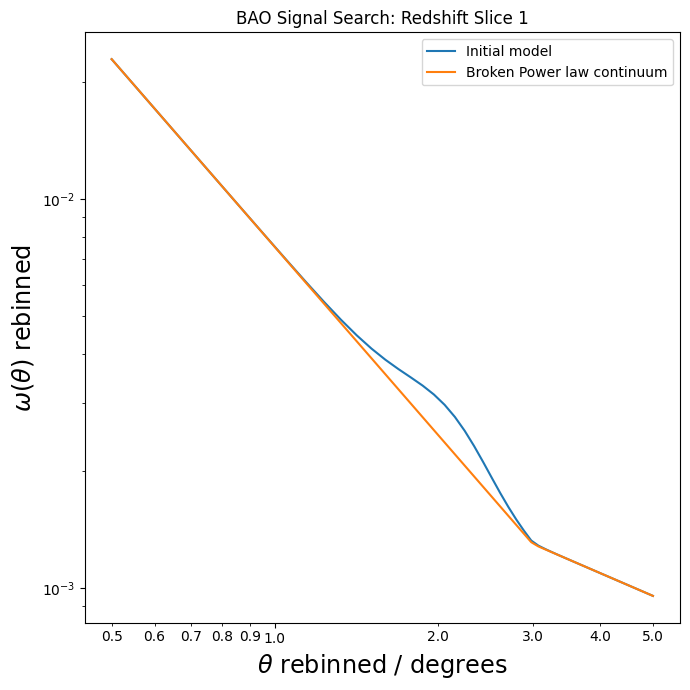

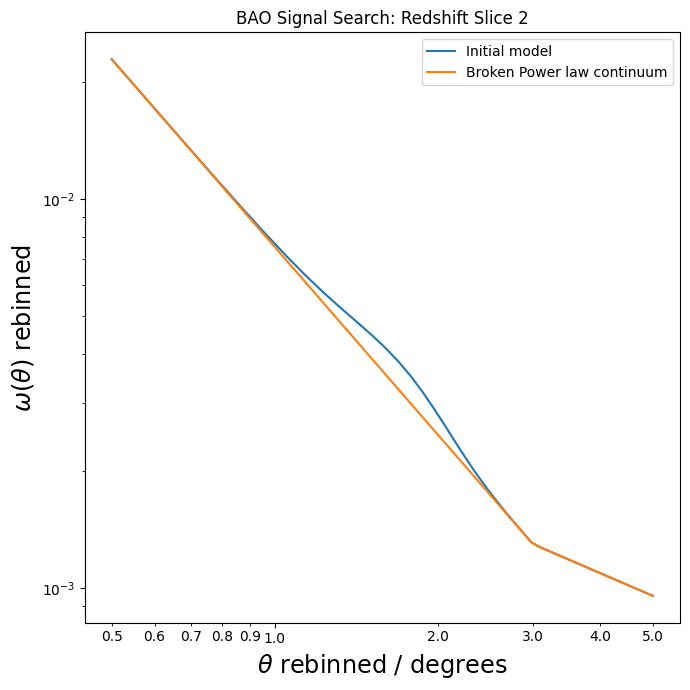

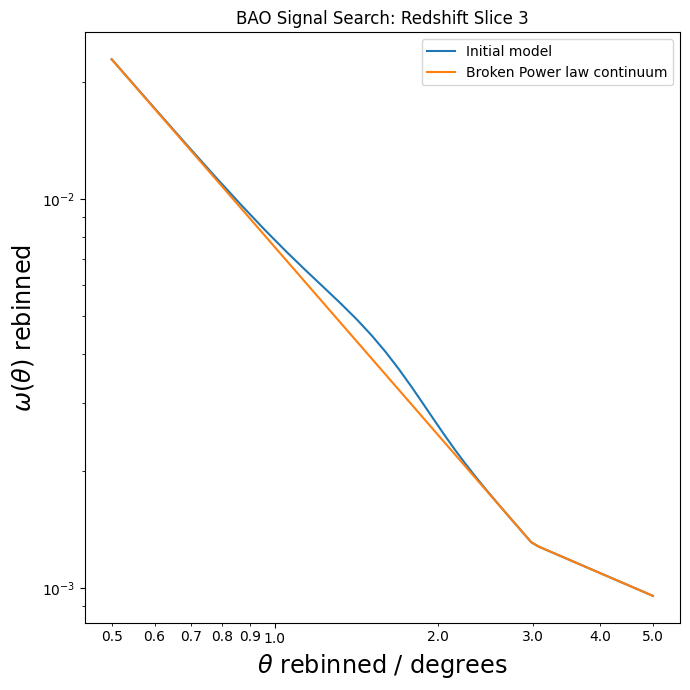

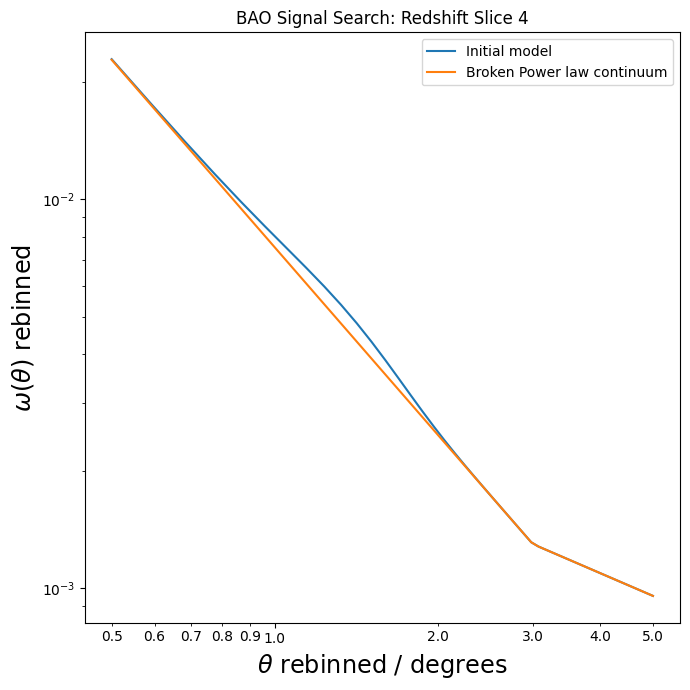

In [90]:
# Guesses for each bao location
guesses = [2.0, 1.6, 1.4, 1.2]
final_bao_scales = []
final_bao_uncertainties = []

# initial guesses for parameters
bao_norm = 6e-4  # normalisation of the gaussian BAO signal component
bao_sigma = 0.5  # sigma of the gaussian BAO signal component
pl_index_1 = -1.6  # index of the broken power law component below the break
pl_index_2 = -0.6  # index of the broken power law component above the break
pl_norm = 1.3e-3  # normalisation of the broken power law component
pl_break = 3  # value of theta at which the power law breaks


for i in range(4):
    print(f"Fitting Model #{i+1}...")
    # Prepare data for the specific bin
    theta = results_theta[i]
    omega = results_omega[i]
    omega_errors = np.sqrt(results_var[i])

    current_bao_guess = guesses[i]

    initial_parameter_guesses = np.array([
        bao_norm,     
        current_bao_guess,
        bao_sigma,
        pl_index_1,
        pl_index_2,
        pl_norm,
        pl_break,
    ])

    theta_grid = np.linspace(0.5, 5, 50)
    
    initial_model_values = model(
        theta_grid,
        initial_parameter_guesses,
    )

    # Create a figure
    fig = plt.figure(figsize=(7, 7))

    # Create a set of axes attached to our figure
    ax = fig.add_subplot(1, 1, 1)
    
    # Use the `plot` method of our axes object to plot the initial model
    ax.plot(
        theta_grid,  # values of theta to plot the initial model for
        initial_model_values,  # values of the initial model
        label="Initial model",  # Add a label that will be shown in the legend for this plot
    )
    
    initial_continuum_values = bkn_powerlaw(
        theta_grid,  # values of theta to plot the initial model for
        pl_norm,  # the brokemn power law normalisation
        pl_index_1,  # index of the broken power law component below the break
        pl_index_2,  # index of the broken power law component above the break
        pl_break,  # value of theta at which the power law breaks
    )
    
    # Use the `plot` method of our axes object to plot the initial continuum model
    ax.plot(
        theta_grid,  # values of theta to plot the initial model for
        initial_continuum_values,  # values of the initial continuum model
        label="Broken Power law continuum",  # Add a label that will be shown in the legend for this plot
    )
    
    # Set the x and y axes to display logarithmic scales
    ax.set_yscale("log")
    ax.set_xscale("log")
    
    # Fiddly formatting to improve the x-axis labels 
    ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:.1f}'))
    ax.xaxis.set_minor_formatter(ticker.StrMethodFormatter('{x:.1f}'))
    
    # Set the x and y axes' titles
    ax.set_ylabel(r"$\omega(\theta)$ rebinned", fontsize="xx-large")
    ax.set_xlabel(r"$\theta$ rebinned / degrees", fontsize="xx-large")
    
    # Add a legend to our axes
    ax.legend()
    ax.set_title(f"BAO Signal Search: Redshift Slice {i+1}")
    
    # Tidy up the plot
    plt.tight_layout()
        

e)

We will start by plotting $\theta$ against $\chi^2$, following code provided in part 6.


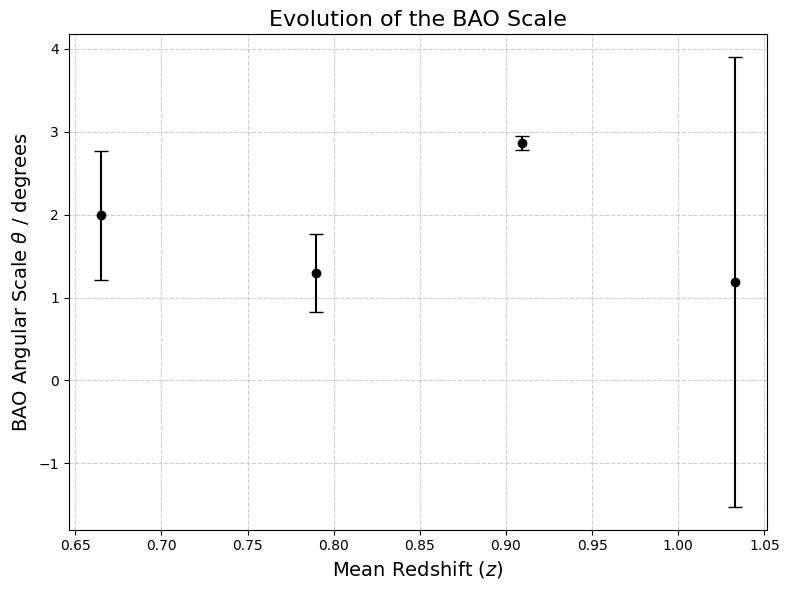

[np.float64(1.992525421525308),
 np.float64(1.2995176901250143),
 np.float64(2.8699377259223002),
 np.float64(1.1874102482197968)]

In [93]:
final_bao_scales, final_bao_errors = [], []

# Define the parameter bounds, this will be the same as Pracitcal Cosmology 3, but with tweaked
# bounds on normalisation of the gaussian BAO signal component
# Note that we do not place an upper bound on this parameter.
bao_norm_bounds = [1e-4, None]
# bounds on mean of the gaussian BAO signal component (Tweaked since our values fall between 1.0-2.0
bao_location_bounds = [1.0, 4]
# bounds on sigma of the gaussian BAO signal component
bao_sigma_bounds = [0.3, 0.75]
# bounds on index of the broken power law component below the break
# Note that we restrict this to be negative, implying a falling power
# law.
pl_index_1_bounds = [-5, -1]
# bounds on index of the broken power law component above the break
# Note that we allow this to be slightly positive.
pl_index_2_bounds = [-5, 1]
# bounds on normalisation of the broken power law component
# Note that we do not place an upper bound on this parameter.
pl_norm_bounds = [1e-4, None]
# bounds on value of theta at which the power law breaks
# Note that we allow a large range of values because we do
# not need the continuum model to be physically meaningful
# but we do need it to be flexible.
pl_break_bounds = [2, 7]


# collect the parameter bounds together into a numpy array in the
# order that is expected by our `model` function.
parameter_bounds = np.array(
    [
        bao_norm_bounds,
        bao_location_bounds,
        bao_sigma_bounds,
        pl_index_1_bounds,
        pl_index_2_bounds,
        pl_norm_bounds,
        pl_break_bounds,
    ]
)

for i in range(4):
    theta = results_theta[i]
    omega = results_omega[i]
    var = results_var[i]
    theta_rebinned, omega_rebinned, omega_var_rebinned = rebin(theta, omega, var, points_to_combine=5)

    current_bao_guess = guesses[i]
    initial_parameter_guesses = np.array([
        bao_norm,     
        current_bao_guess,
        bao_sigma,
        pl_index_1,
        pl_index_2,
        pl_norm,
        pl_break,
    ])
    
    fit_results = imin.minimize(
        fit_function,
        x0=initial_parameter_guesses,
        args=[theta_rebinned, omega_rebinned, np.sqrt(omega_var_rebinned)],
        bounds=parameter_bounds,
        options=dict(stra=2, maxfun=10000),  # You should not need to change these options
    )

    # test the value of the success attribute
    if fit_results.success:        
        fit_results.minuit.errordef = fit_results.minuit.LEAST_SQUARES
        fit_results.minuit.hesse()

        best_theta = fit_results.x[1]
        error_theta = fit_results.minuit.errors[1]

        final_bao_scales.append(best_theta)
        final_bao_errors.append(error_theta)
    else:
        # if False, print that the fit failed and the message which may provide clues about why
        final_bao_scales.append(np.nan)
        final_bao_errors.append(np.nan)

# Create the figure
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)

# Plot the measurements
ax.errorbar(
    z_mean_vals,             # Your 4 mean redshift values
    final_bao_scales,        # The 4 scales from your loop
    yerr=final_bao_errors,   # The uncertainties from hesse()
    fmt='o', 
    color='black', 
    capsize=5, 
    label='Measured BAO scale'
)

# Formatting
ax.set_xlabel('Mean Redshift ($z$)', fontsize=14)
ax.set_ylabel(r'BAO Angular Scale $\theta$ / degrees', fontsize=14)
ax.set_title('Evolution of the BAO Scale', fontsize=16)
ax.grid(True, linestyle='--', alpha=0.6)


plt.tight_layout()
plt.show()

final_bao_scales

Slices 1, 2 and 4 demonstrate a physically consistent reduction in the angular BAO scale $(\theta)$ with increasing redshift ($z$), however Slice 3 $(\theta\approx 2.87)$ represents a statistical outlier, meaning the outlier failed to isolate the true BAO feature.

f)

3/4 of the slices used were consistent. To test this, I will use 6 equidistant slices, instead of 5 as earlier.